# Twitter Sentiment Classification (4-Class)
Full pipeline: load → clean → preprocess (bug fixed) → TF-IDF → train 3 classical models → train a Bidirectional GRU deep learning model → evaluate all 4 → feature importance → save.

## 1. Imports

In [1]:
import re
import joblib
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Deep learning (GRU) imports
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

stemmer = PorterStemmer()
STOPWORDS = set(stopwords.words('english'))


**Note:** if `stopwords.words('english')` fails with a `LookupError`, run the cell below once to download NLTK's stopword data, then rerun the cell above.

In [2]:
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 2. Load Data (all 4 classes kept — Positive, Negative, Neutral, Irrelevant)

In [3]:
import csv

def load_tweets(file_name):
    """Load a tweet CSV and return the DataFrame with all 4 sentiment classes intact.

    Uses the Python parsing engine + QUOTE_NONE because this dataset contains stray/unclosed
    quote characters in some tweet text, which breaks pandas' default C parser with an
    'EOF inside string' error. The Python engine + QUOTE_NONE treats " as a normal character
    instead of a field-quoting marker, avoiding that failure.
    """
    df = pd.read_csv(
        file_name,
        header=None,
        engine='python',
        on_bad_lines='skip',
        quoting=csv.QUOTE_NONE,
    )
    df = df.rename({0: 'id', 1: 'company', 2: 'sentiment', 3: 'raw_tweet'}, axis=1)
    df = df.dropna(subset=['raw_tweet', 'sentiment'])
    df = df.drop_duplicates(subset=['raw_tweet'])
    return df

df_train = load_tweets('tweets/twitter_training.csv')
df_val   = load_tweets('tweets/twitter_validation.csv')

print('Train shape:', df_train.shape)
print('Validation shape:', df_val.shape)
df_train.head()


Train shape: (61343, 5)
Validation shape: (987, 7)


,id,company,sentiment,raw_tweet,4
0,2401,Borderlands,Positive,"""im getting on borderlands and i will murder y...",""""
1,2401,Borderlands,Positive,"""I am coming to the borders and I will kill yo...",""""
2,2401,Borderlands,Positive,"""im getting on borderlands and i will kill you...",""""
3,2401,Borderlands,Positive,"""im coming on borderlands and i will murder yo...",""""
4,2401,Borderlands,Positive,"""im getting on borderlands 2 and i will murder...",""""


## 3. Exploratory Data Analysis
Check class balance before doing anything else — this tells us whether we need stratified splitting or class weighting.

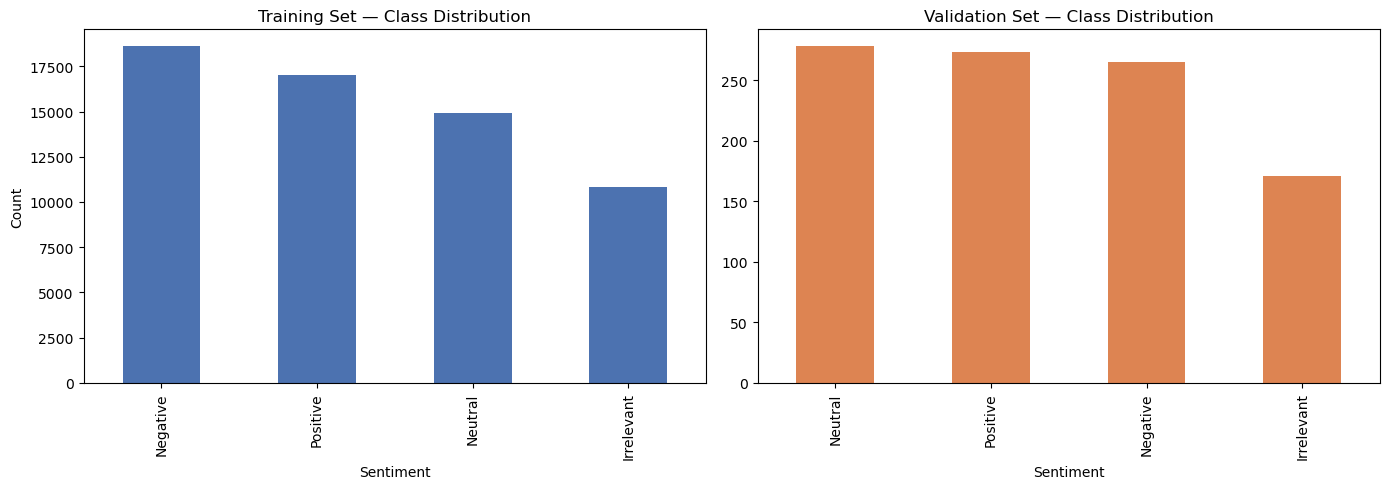

sentiment
Negative      0.303
Positive      0.277
Neutral       0.243
Irrelevant    0.177
Name: proportion, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_train['sentiment'].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Training Set — Class Distribution')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')

df_val['sentiment'].value_counts().plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Validation Set — Class Distribution')
axes[1].set_xlabel('Sentiment')

plt.tight_layout()
plt.show()

print(df_train['sentiment'].value_counts(normalize=True).round(3))


## 4. Text Preprocessing (bug fixed)
**The original bug:** this function built `processed_tweets` correctly but returned the original `tweets` list instead.
Fixed version below actually returns the cleaned tokens.

In [5]:
def preprocess_tweet(tweet):
    """Clean a single tweet: strip non-letters, lowercase, remove stopwords, stem."""
    tweet = re.sub(r'[^a-zA-Z]', ' ', str(tweet))
    tweet = tweet.lower()
    tokens = [word for word in tweet.split() if word not in STOPWORDS]
    tokens = [stemmer.stem(word) for word in tokens if len(word) > 0]
    return ' '.join(tokens)

def preprocess_series(tweets):
    return tweets.apply(preprocess_tweet)

df_train['clean_tweet'] = preprocess_series(df_train['raw_tweet'])
df_val['clean_tweet']   = preprocess_series(df_val['raw_tweet'])

# Sanity check — confirm cleaning actually changed the text (this is the check that would
# have caught the original bug immediately)
print('BEFORE:', df_train['raw_tweet'].iloc[0])
print('AFTER :', df_train['clean_tweet'].iloc[0])


BEFORE: "im getting on borderlands and i will murder you all 
AFTER : im get borderland murder


## 4.1 Word Clouds by Sentiment Class
A quick, qualitative EDA visual — built from the **cleaned** text (post stopword-removal/stemming) so common filler words don't dominate. Note: this is exploratory only, not a substitute for the model-driven feature importance analysis in Section 11 — word size here just reflects raw frequency, not how distinctive a word is to one class over another.

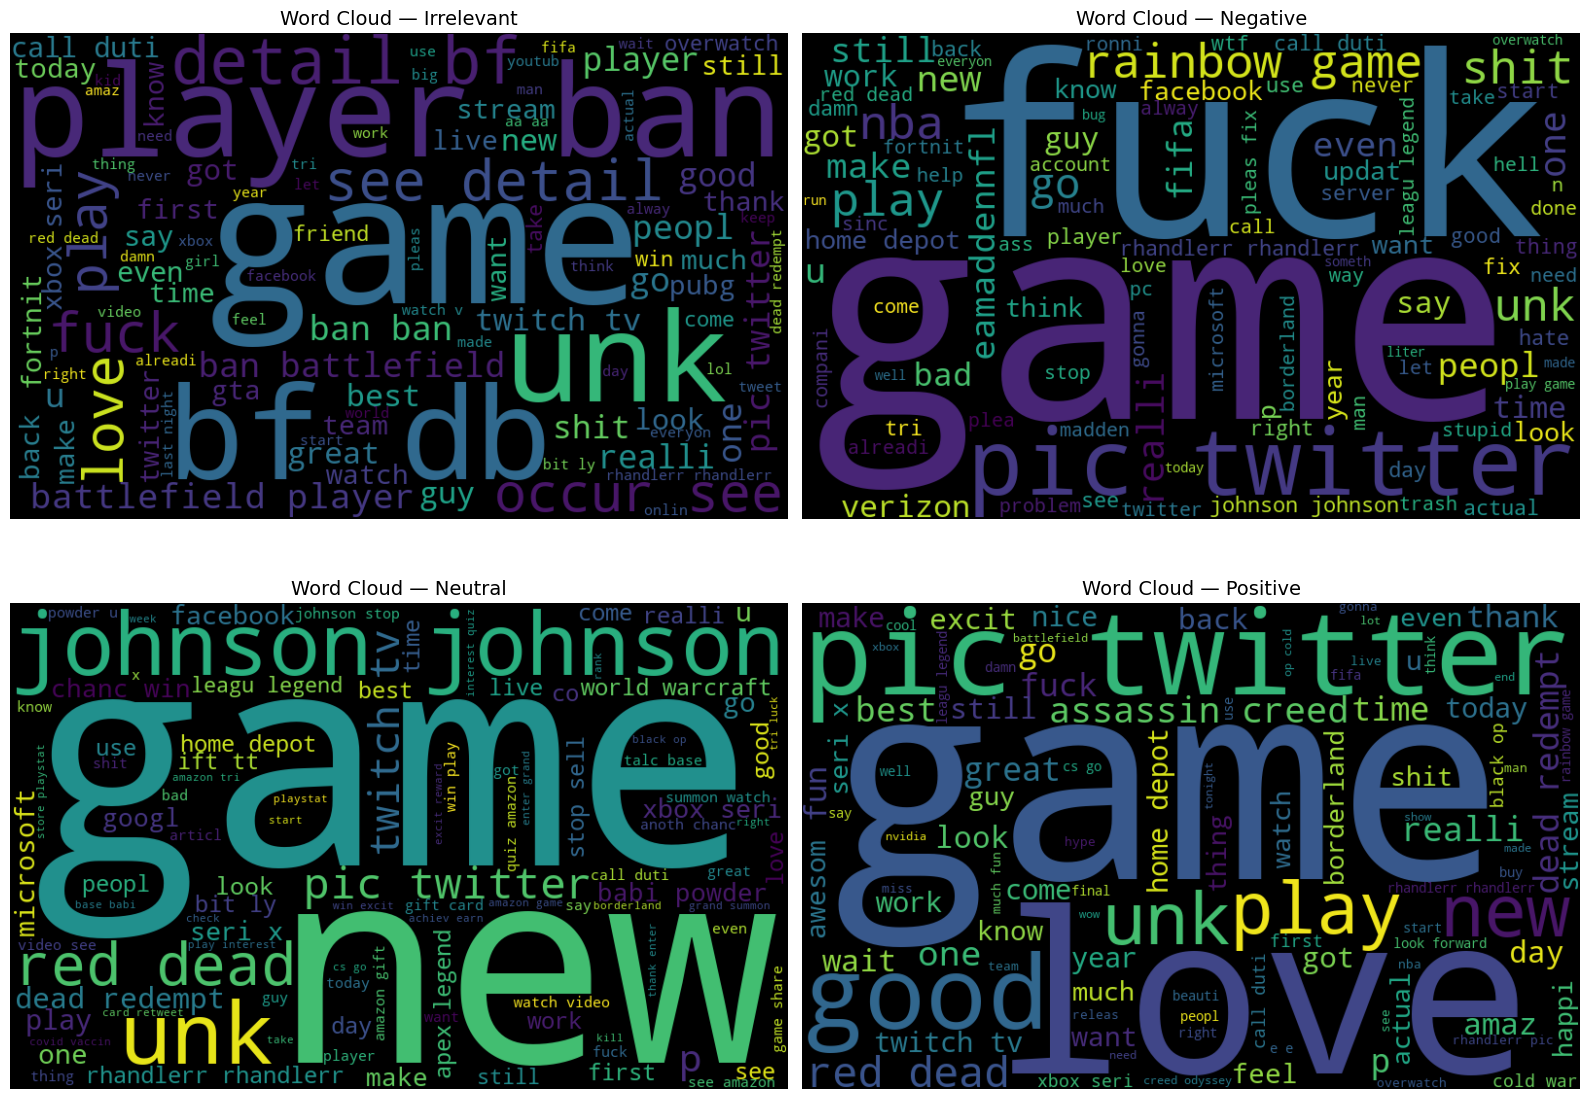

In [6]:
from wordcloud import WordCloud

# If this import fails, run:  pip install wordcloud
classes = df_train['sentiment'].unique()
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, sentiment_class in zip(axes, sorted(classes)):
    text_for_class = ' '.join(df_train.loc[df_train['sentiment'] == sentiment_class, 'clean_tweet'])
    wc = WordCloud(width=800, height=500, max_words=100, colormap='viridis').generate(text_for_class)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'Word Cloud — {sentiment_class}', fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()


## 5. Label Encoding (4 classes)


In [7]:
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(df_train['sentiment'])
y_val   = label_encoder.transform(df_val['sentiment'])

print('Classes:', list(label_encoder.classes_))
print('Encoded example:', df_train['sentiment'].iloc[0], '->', y_train[0])


Classes: ['Irrelevant', 'Negative', 'Neutral', 'Positive']
Encoded example: Positive -> 3


## 6. TF-IDF Feature Extraction (for the 3 classical models)


In [8]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(df_train['clean_tweet'])
X_val_tfidf   = tfidf.transform(df_val['clean_tweet'])

print('Train feature matrix:', X_train_tfidf.shape)
print('Validation feature matrix:', X_val_tfidf.shape)


Train feature matrix: (61343, 5000)
Validation feature matrix: (987, 5000)


## 7. Train the 3 Classical Models

In [9]:
classical_models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM (OvR)': LinearSVC(max_iter=5000),
}

trained_models = {}
for name, model in classical_models.items():
    print(f'Training {name}...')
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model

print('All classical models trained.')


Training Multinomial Naive Bayes...
Training Logistic Regression...
Training Linear SVM (OvR)...
All classical models trained.


## 8. Prepare Sequence Data for the GRU


In [10]:
MAX_VOCAB = 10000
MAX_LEN = 40   # tweets are short — 40 tokens comfortably covers most of them

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df_train['clean_tweet'])

train_sequences = tokenizer.texts_to_sequences(df_train['clean_tweet'])
val_sequences   = tokenizer.texts_to_sequences(df_val['clean_tweet'])

X_train_seq = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_seq   = pad_sequences(val_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)
print('Vocab size used:', vocab_size)
print('Example padded sequence:', X_train_seq[0])


Vocab size used: 10000
Example padded sequence: [ 174    5   74 1154    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0]


## 9. Build and Train the Bidirectional GRU Model

In [11]:
EMBEDDING_DIM = 128
NUM_CLASSES = len(label_encoder.classes_)

gru_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(GRU(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax'),
])

gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

gru_model.summary()


C:\Users\User\anaconda3\envs\ml-zoomcamp\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = gru_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[early_stop],
)


Epoch 1/15
959/959 ━━━━━━━━━━━━━━━━━━━━ 82s 75ms/step - accuracy: 0.6322 - loss: 0.9088 - val_accuracy: 0.7964 - val_loss: 0.5494
Epoch 2/15
959/959 ━━━━━━━━━━━━━━━━━━━━ 63s 66ms/step - accuracy: 0.8102 - loss: 0.5220 - val_accuracy: 0.8419 - val_loss: 0.4248
Epoch 3/15
959/959 ━━━━━━━━━━━━━━━━━━━━ 73s 76ms/step - accuracy: 0.8541 - loss: 0.4002 - val_accuracy: 0.8673 - val_loss: 0.3930
Epoch 4/15
959/959 ━━━━━━━━━━━━━━━━━━━━ 68s 71ms/step - accuracy: 0.8753 - loss: 0.3452 - val_accuracy: 0.8693 - val_loss: 0.4000
Epoch 5/15
959/959 ━━━━━━━━━━━━━━━━━━━━ 73s 76ms/step - accuracy: 0.8871 - loss: 0.3045 - val_accuracy: 0.8734 - val_loss: 0.3982
Epoch 6/15
959/959 ━━━━━━━━━━━━━━━━━━━━ 64s 66ms/step - accuracy: 0.8989 - loss: 0.2738 - val_accuracy: 0.8815 - val_loss: 0.3755
Epoch 7/15
959/959 ━━━━━━━━━━━━━━━━━━━━ 64s 67ms/step - accuracy: 0.9068 - loss: 0.2489 - val_accuracy: 0.8835 - val_loss: 0.3821
Epoch 8/15
959/959 ━━━━━━━━━━━━━━━━━━━━ 57s 59ms/step - accuracy: 0.9122 - loss: 0.2303 - 

### 9.1 Training Curves
Watch for the validation loss curve turning upward while training loss keeps falling — that's overfitting, and worth mentioning in the report if it happens, since it's a genuine risk with a from-scratch embedding on a modest dataset.

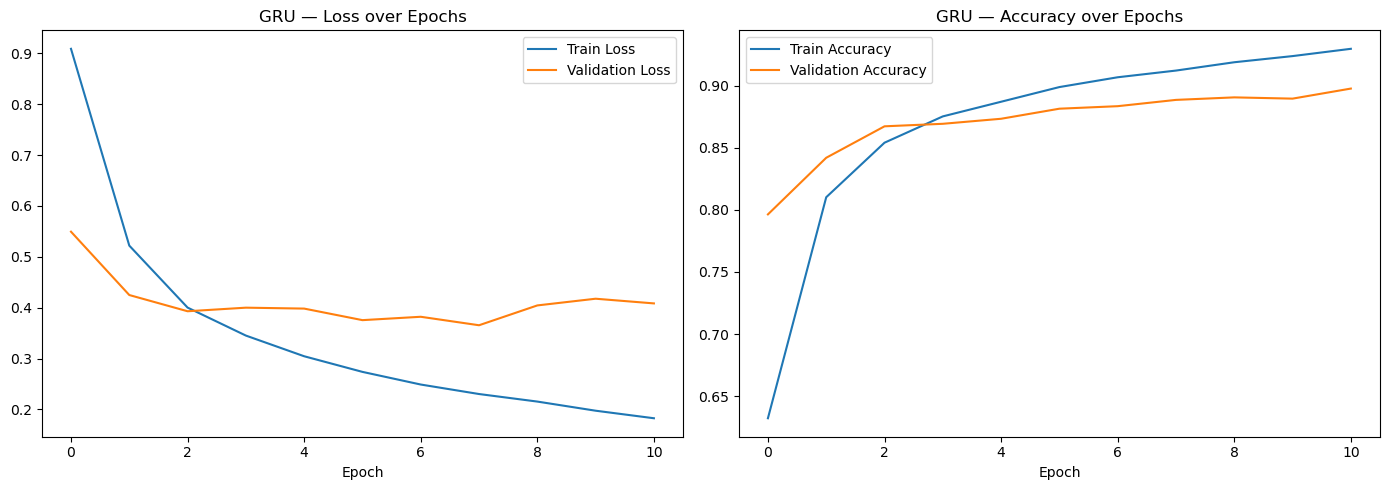

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('GRU — Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('GRU — Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


## 10. Evaluate All 4 Models Together
Same metrics (accuracy, macro F1) computed the same way for every model, classical or deep learning, so the comparison table is genuinely apples-to-apples.

In [14]:
results = []

# Classical models (TF-IDF based)
for name, model in trained_models.items():
    preds = model.predict(X_val_tfidf)
    acc = accuracy_score(y_val, preds)
    macro_f1 = f1_score(y_val, preds, average='macro')
    results.append({'Model': name, 'Accuracy': round(acc, 4), 'Macro F1': round(macro_f1, 4)})
    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}  |  Macro F1: {macro_f1:.4f}')
    print(classification_report(y_val, preds, target_names=label_encoder.classes_))

# GRU model (sequence based)
gru_probs = gru_model.predict(X_val_seq)
gru_preds = np.argmax(gru_probs, axis=1)
gru_acc = accuracy_score(y_val, gru_preds)
gru_macro_f1 = f1_score(y_val, gru_preds, average='macro')
results.append({'Model': 'Bidirectional GRU + Embedding', 'Accuracy': round(gru_acc, 4), 'Macro F1': round(gru_macro_f1, 4)})

print('\n=== Bidirectional GRU + Embedding ===')
print(f'Accuracy: {gru_acc:.4f}  |  Macro F1: {gru_macro_f1:.4f}')
print(classification_report(y_val, gru_preds, target_names=label_encoder.classes_))

results_df = pd.DataFrame(results).sort_values('Macro F1', ascending=False)
results_df



=== Multinomial Naive Bayes ===
Accuracy: 0.6616  |  Macro F1: 0.6498
              precision    recall  f1-score   support

  Irrelevant       0.78      0.51      0.62       171
    Negative       0.61      0.83      0.70       265
     Neutral       0.76      0.47      0.58       278
    Positive       0.63      0.79      0.70       273

    accuracy                           0.66       987
   macro avg       0.69      0.65      0.65       987
weighted avg       0.69      0.66      0.65       987


=== Logistic Regression ===
Accuracy: 0.7579  |  Macro F1: 0.7531
              precision    recall  f1-score   support

  Irrelevant       0.76      0.69      0.72       171
    Negative       0.75      0.86      0.80       265
     Neutral       0.84      0.64      0.73       278
    Positive       0.71      0.82      0.76       273

    accuracy                           0.76       987
   macro avg       0.76      0.75      0.75       987
weighted avg       0.77      0.76      0.76    

,Model,Accuracy,Macro F1
3,Bidirectional GRU + Embedding,0.8886,0.8895
2,Linear SVM (OvR),0.7893,0.7840
1,Logistic Regression,0.7579,0.7531
0,Multinomial Naive Bayes,0.6616,0.6498


### 10.1 Confusion Matrices — All 4 Models

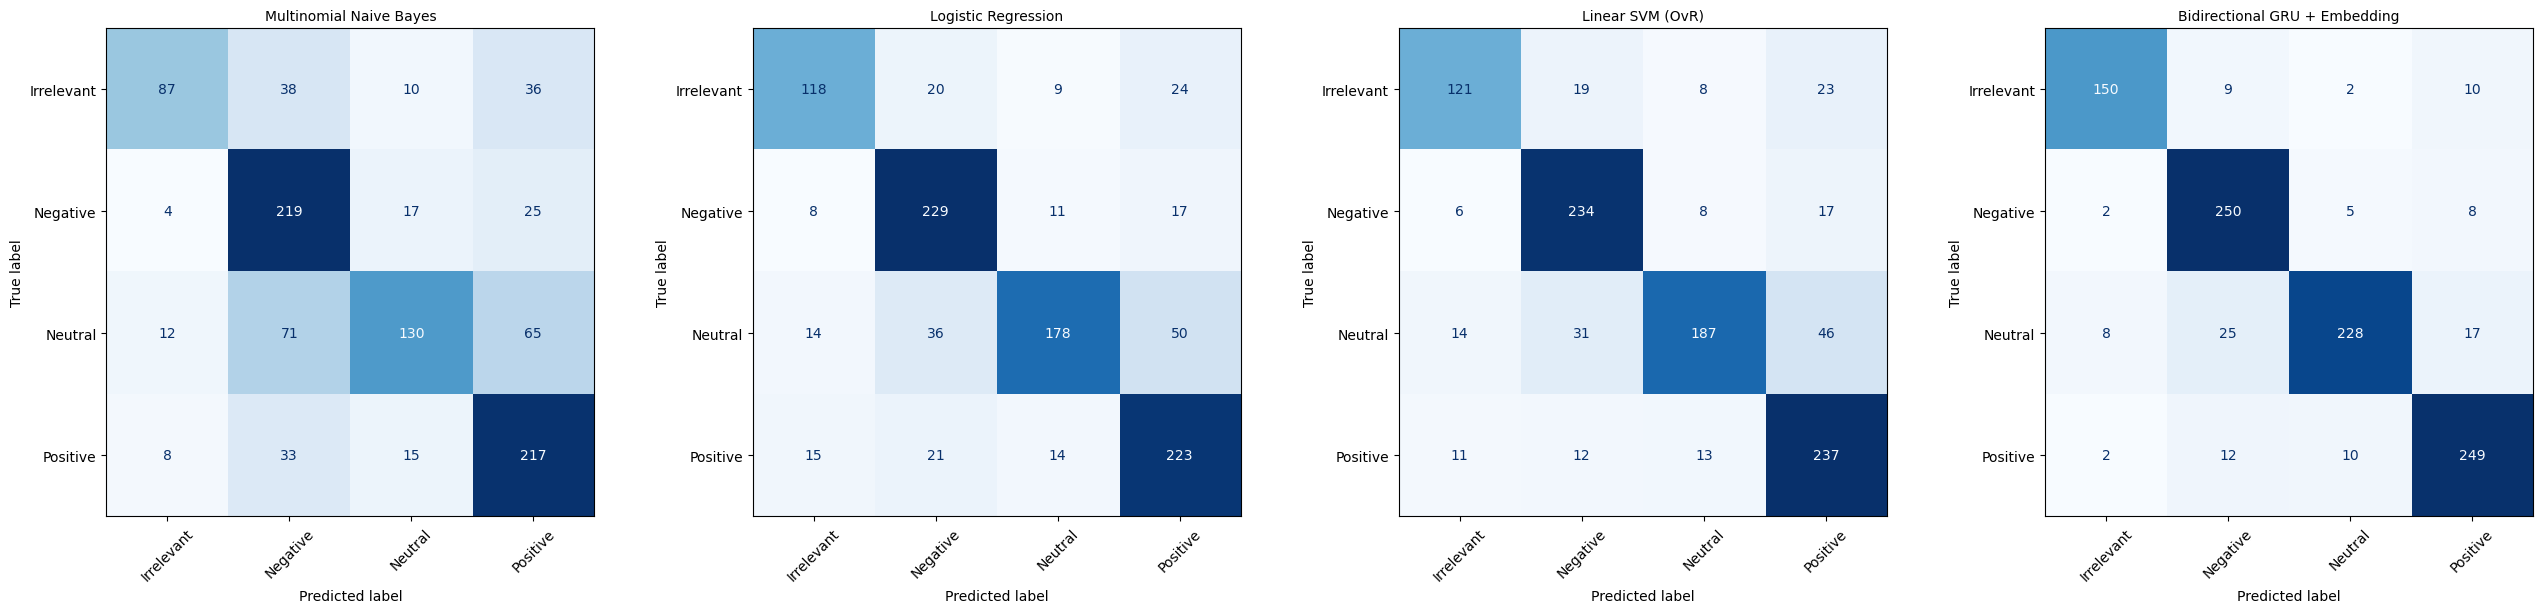

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(26, 6))

all_preds = {name: model.predict(X_val_tfidf) for name, model in trained_models.items()}
all_preds['Bidirectional GRU + Embedding'] = gru_preds

for ax, (name, preds) in zip(axes, all_preds.items()):
    cm = confusion_matrix(y_val, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
    ax.set_title(name, fontsize=10)

plt.tight_layout()
plt.show()


## 11. Feature Importance — Top Words per Class (Logistic Regression)


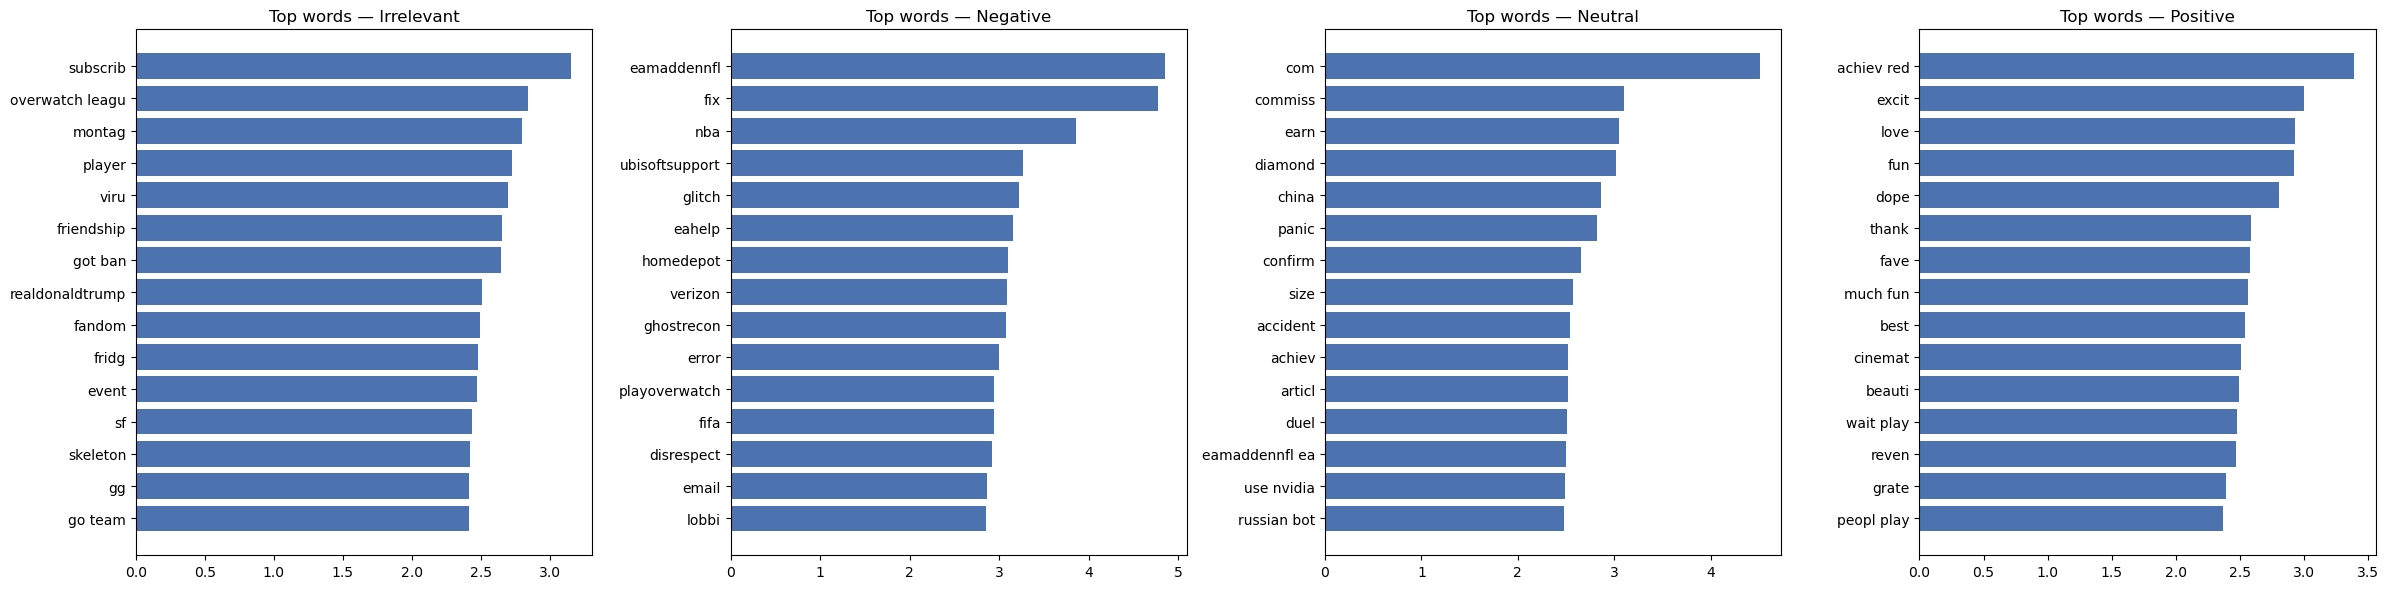

In [16]:
logreg = trained_models['Logistic Regression']
feature_names = np.array(tfidf.get_feature_names_out())

n_top = 15
fig, axes = plt.subplots(1, len(label_encoder.classes_), figsize=(24, 6))

for i, class_name in enumerate(label_encoder.classes_):
    coefs = logreg.coef_[i]
    top_idx = np.argsort(coefs)[-n_top:]
    top_words = feature_names[top_idx]
    top_scores = coefs[top_idx]

    axes[i].barh(top_words, top_scores, color='#4C72B0')
    axes[i].set_title(f'Top words — {class_name}')

plt.tight_layout()
plt.show()


## 12. Sample Predictions


In [17]:
# --- 12.1 Spot-check real validation tweets across all 4 models ---
sample_idx = np.random.RandomState(42).choice(len(df_val), size=8, replace=False)

sample_df = df_val.iloc[sample_idx].copy()
sample_X_tfidf = tfidf.transform(sample_df['clean_tweet'])
sample_X_seq = pad_sequences(
    tokenizer.texts_to_sequences(sample_df['clean_tweet']), maxlen=MAX_LEN, padding='post', truncating='post'
)

for name, model in trained_models.items():
    sample_df[name] = label_encoder.inverse_transform(model.predict(sample_X_tfidf))

sample_df['Bidirectional GRU + Embedding'] = label_encoder.inverse_transform(
    np.argmax(gru_model.predict(sample_X_seq), axis=1)
)

display_cols = ['raw_tweet', 'sentiment'] + list(trained_models.keys()) + ['Bidirectional GRU + Embedding']
sample_df[display_cols].rename(columns={'sentiment': 'True Label'})


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step


,raw_tweet,True Label,Multinomial Naive Bayes,Logistic Regression,Linear SVM (OvR),Bidirectional GRU + Embedding
437,"""Whos ready for some zombie royale warzone str...",Neutral,Irrelevant,Irrelevant,Irrelevant,Neutral
193,"""The OGA Dota PIT Season 3: Europe/CIS looks l...",Neutral,Neutral,Neutral,Neutral,Neutral
741,Maybe the greatest musical moment in a video g...,Positive,Positive,Positive,Positive,Positive
1285,"""1. buy CS:GO or TF2 item off SCM",Neutral,Neutral,Neutral,Neutral,Neutral
113,"""Play with @PtitDrogo and @BlyOnFire starting ...",Neutral,Neutral,Neutral,Neutral,Neutral
567,"""THIS IS INSANE!!!!!!!!!!!!!!!!!!!!",Positive,Positive,Positive,Positive,Positive
1370,"""Former Arsenal and West Ham player Alex Song ...",Irrelevant,Irrelevant,Irrelevant,Irrelevant,Irrelevant
138,"""RED DEAD REDEMPTION 2",Neutral,Neutral,Neutral,Neutral,Neutral


In [18]:
# --- 12.2 Predict sentiment on new, custom text (live demo function) ---
def predict_sentiment(text, model_name='Logistic Regression'):
    """Predict sentiment for a single piece of text using any trained model by name,
    including 'Bidirectional GRU + Embedding'."""
    cleaned = preprocess_tweet(text)

    if model_name == 'Bidirectional GRU + Embedding':
        seq = pad_sequences(tokenizer.texts_to_sequences([cleaned]), maxlen=MAX_LEN, padding='post', truncating='post')
        pred = np.argmax(gru_model.predict(seq, verbose=0), axis=1)[0]
    else:
        vec = tfidf.transform([cleaned])
        pred = trained_models[model_name].predict(vec)[0]

    return label_encoder.inverse_transform([pred])[0]

# Try it on a few made-up examples
demo_tweets = [
    "I absolutely love the new update, this is amazing!",
    "This is the worst service I have ever experienced.",
    "The company released a new product yesterday.",
    "I don't even know what this tweet is about, random text here.",
]

for tweet in demo_tweets:
    for model_name in list(trained_models.keys()) + ['Bidirectional GRU + Embedding']:
        print(f'[{model_name:28s}] "{tweet}" -> {predict_sentiment(tweet, model_name)}')
    print()


[Multinomial Naive Bayes     ] "I absolutely love the new update, this is amazing!" -> Positive
[Logistic Regression         ] "I absolutely love the new update, this is amazing!" -> Positive
[Linear SVM (OvR)            ] "I absolutely love the new update, this is amazing!" -> Positive
[Bidirectional GRU + Embedding] "I absolutely love the new update, this is amazing!" -> Positive

[Multinomial Naive Bayes     ] "This is the worst service I have ever experienced." -> Negative
[Logistic Regression         ] "This is the worst service I have ever experienced." -> Negative
[Linear SVM (OvR)            ] "This is the worst service I have ever experienced." -> Negative
[Bidirectional GRU + Embedding] "This is the worst service I have ever experienced." -> Positive

[Multinomial Naive Bayes     ] "The company released a new product yesterday." -> Negative
[Logistic Regression         ] "The company released a new product yesterday." -> Negative
[Linear SVM (OvR)            ] "The company re

## 13. Save the Best Model + Preprocessing Artifacts


In [19]:
best_row = results_df.iloc[0]
best_model_name = best_row['Model']
print('Best model overall:', best_model_name, '| Macro F1:', best_row['Macro F1'])

joblib.dump(tfidf, 'tfidf_vectorizer.joblib')
joblib.dump(label_encoder, 'label_encoder.joblib')

if best_model_name == 'Bidirectional GRU + Embedding':
    gru_model.save('best_sentiment_model_gru.keras')
    with open('tokenizer.pkl', 'wb') as f:
        pickle.dump(tokenizer, f)
    print('Saved: best_sentiment_model_gru.keras, tokenizer.pkl, tfidf_vectorizer.joblib, label_encoder.joblib')
else:
    pickle.dump(trained_models[best_model_name], open('best_sentiment_model.pkl', 'wb'))
    print('Saved: best_sentiment_model.pkl, tfidf_vectorizer.joblib, label_encoder.joblib')


Best model overall: Bidirectional GRU + Embedding | Macro F1: 0.8895
Saved: best_sentiment_model_gru.keras, tokenizer.pkl, tfidf_vectorizer.joblib, label_encoder.joblib


In [20]:
Tweeter-X-Sentiment-Analysis

NameError: name 'Tweeter' is not defined